In [79]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import onnxruntime as ort

from pathlib import Path

In [80]:
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "dataset"
MODEL_DIR = PROJECT_ROOT / "models"

TEST_DIR = DATASET_DIR / "test"
MODEL_PATH = MODEL_DIR / "mobilenetv2_best.pth"
ONNX_MODEL_PATH = MODEL_DIR / "mobilenetv2.onnx"

RESULTS_DIR = PROJECT_ROOT / "models" / "results"
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

In [81]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

In [82]:
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_dataset = ImageFolder(TEST_DIR, transform=val_test_transform)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [83]:
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v2(pretrained=False)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 2)
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully.")

c:\Users\cadg0\Downloads\CSC173-DeepCV-Gumisad\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\cadg0\Downloads\CSC173-DeepCV-Gumisad\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully.


In [84]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [85]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9933333333333333


In [86]:
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes,
    output_dict=True
)

import json

with open(RESULTS_DIR / "classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=4)

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       150
           1       1.00      0.99      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



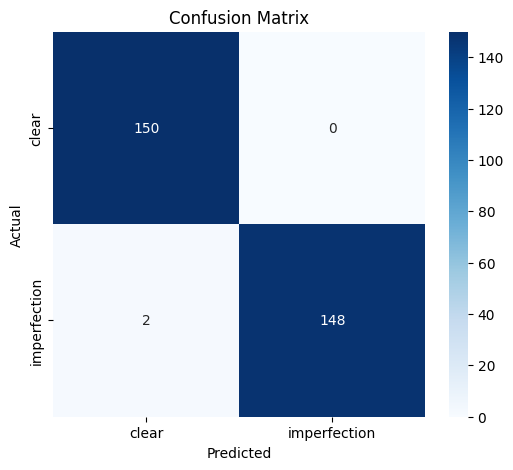

In [87]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(RESULTS_DIR / "confusion_matrix.png")
plt.show()

In [88]:
import random
import cv2

misclassified = []

for i in range(len(all_preds)):
    if all_preds[i] != all_labels[i]:
        misclassified.append(i)

print("Misclassified samples:", len(misclassified))

Misclassified samples: 2


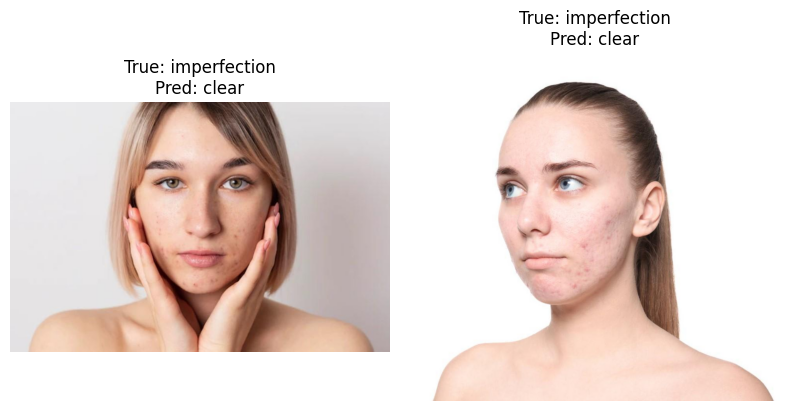

In [89]:
plt.figure(figsize=(12,8))

for i in range(min(6, len(misclassified))):
    
    idx = misclassified[i]
    
    img_path, label = test_dataset.samples[idx]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(
        f"True: {test_dataset.classes[all_labels[idx]]}\nPred: {test_dataset.classes[all_preds[idx]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "misclassified_samples.png")
plt.show()

In [90]:
onnx_session = ort.InferenceSession(str(ONNX_MODEL_PATH))
input_name = onnx_session.get_inputs()[0].name

In [91]:
inference_times = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        start = time.time()

        outputs = model(images)

        end = time.time()

        inference_times.append((end - start) / images.size(0))  # per image

In [92]:
avg_time = np.mean(inference_times)
fps = 1 / avg_time

speed_report = f"""
Average Inference Time (ms): {avg_time * 1000:.2f}
Frames Per Second (FPS): {fps:.2f}
"""

print(speed_report)

with open(RESULTS_DIR / "inference_speed.txt", "w") as f:
    f.write(speed_report)


Average Inference Time (ms): 39.94
Frames Per Second (FPS): 25.04

